# LaCAM + PIBT + primitive demo
This notebook builds the dependency-free C++ planner, runs the crossing example, and displays the generated GIF inline.

In [1]:
from pathlib import Path
import subprocess, sys, yaml
from IPython.display import Image, display
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'python'))
from lacam_primitive_viz import plan_and_animate

In [2]:
subprocess.run(['cmake', '-S', str(REPO), '-B', str(REPO / 'build'), '-DCMAKE_BUILD_TYPE=Release'], check=True)
subprocess.run(['cmake', '--build', str(REPO / 'build'), '-j2'], check=True)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kakitsu/tel/lacam_primitive/build
[ 60%] Built target lacam_primitive_core
[ 80%] Built target lacam_primitive
[100%] Built target lacam_primitive_tests


CompletedProcess(args=['cmake', '--build', '/home/kakitsu/tel/lacam_primitive/build', '-j2'], returncode=0)

In [3]:
artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'crossing.yaml',
    REPO / 'outputs' / 'notebook',
    time_limit_ms=1000,
    fps=24,
    playback_speed=2.0,
    pixels_per_cell=24,
)
artifacts

solution improved: cost=3.4 weight=3 elapsed_ms=1.43539
Final solution cost: 3.4, elapsed: 1.44032 ms



{'solution': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution.yaml'),
 'animation': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/animation.gif')}

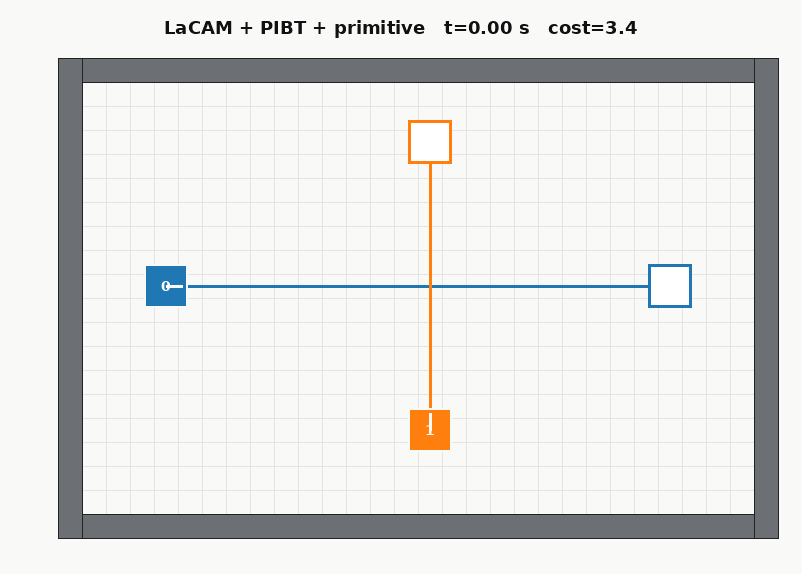

In [4]:
display(Image(filename=str(artifacts['animation'])))

In [5]:
with artifacts['solution'].open(encoding='utf-8') as stream:
    result = yaml.safe_load(stream)
result['improvements'], result['cost']

([{'elapsed_ms': 1.391816, 'cost': 3.4, 'weight': 3}], 3.4)